In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib widget
%config InlineBackend.figure_format='retina'

import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


from mpl_toolkits.mplot3d import Axes3D

from pydmd import DMD
from pydmd.bopdmd import BOPDMD
from pydmd.plotter import plot_eigs
from pydmd.plotter import plot_summary
from pydmd.preprocessing.hankel import hankel_preprocessing

from morphing_birds import Hawk3D, plot, animate, animate_compare

from BirdDMD import runDMD, aggregateDMD

np.set_printoptions(suppress=True, precision=3)



/var/folders/2m/t5bb62r50jbb_r1gf5dsdy680000gr/T/ipykernel_31848/3272105036.py:9: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


## Load Bird Data

## Remove Duplicated Time Frames

Loading Toothless bilateral data with 9m perch distances, with straight turns only, initial.
Dataframe with shape (1531, 38) loaded. Number of sequences: 65


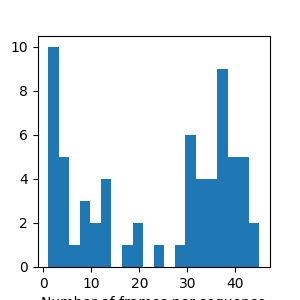

Duplicated frames are 0.0% of the total data.
Skipping sequence 04_09_017_1 due to insufficient timesteps.
Skipping sequence 04_09_018_1 due to insufficient timesteps.
Skipping sequence 04_09_019_1 due to insufficient timesteps.
Skipping sequence 04_09_020_1 due to insufficient timesteps.
Skipping sequence 04_09_021_1 due to insufficient timesteps.
Skipping sequence 04_09_023_1 due to insufficient timesteps.
Skipping sequence 04_09_024_1 due to insufficient timesteps.
Skipping sequence 04_09_025_1 due to insufficient timesteps.
Skipping sequence 04_09_029_1 due to insufficient timesteps.
Skipping sequence 04_09_030_1 due to insufficient timesteps.
Skipping sequence 04_09_031_1 due to insufficient timesteps.
Skipping sequence 04_09_032_1 due to insufficient timesteps.
Skipping sequence 04_09_034_1 due to insufficient timesteps.
Skipping sequence 04_09_036_1 due to insufficient timesteps.
Skipping sequence 04_09_037_1 due to insufficient timesteps.
Skipping sequence 04_09_039_1 due to in

In [223]:
import os

hawk_name = "Toothless"
behaviour = "Initial"
perch_distance = "9m"
turn = "Straight"
nModes = 6

save_path = f"../data/2024-07-09_Bilateral{behaviour}{hawk_name}_{perch_distance}_DMD_results/{str(nModes)}Modes/"

# Check if exists, otherwise create
if not os.path.exists(save_path):
    os.makedirs(save_path)

runDMD.dmd_loop_seqs(hawk_name, 
                    save_path, 
                    behaviour,
                    perch_distance=perch_distance,
                    turn = turn,
                    n_Modes = nModes, 
                    min_seq_length = 20)


In [227]:
# Load results
# DMD_results_6Modes = runDMD.load_dmd_results(wingbeat_df,save_path)
bird_name = "Toothless"
behaviour = "TwoFlaps"
turn = None
nModes = 6

save_path = f"../data/2024-07-09_Bilateral{bird_name}_{perch_distance}_DMD_results/{str(nModes)}Modes/"
print(save_path)
wingbeat_df, marker_column_names = runDMD.load_bird_data(bird_name, behaviour, perch_distance)
DMD_results_12m6Modes = runDMD.load_dmd_results(wingbeat_df,save_path)

behaviour = "Initial"
save_path = f"../data/2024-07-09_BilateralInitial{bird_name}_{perch_distance}_DMD_results/{str(nModes)}Modes/"
print(save_path)
wingbeat_df, marker_column_names = runDMD.load_bird_data(bird_name, behaviour, perch_distance)
DMD_results_Init12m6Modes = runDMD.load_dmd_results(wingbeat_df,save_path)


bird_name = "Charmander"
behaviour = "TwoFlaps"

save_path = f"../data/2024-07-09_Bilateral{bird_name}_{perch_distance}_DMD_results/{str(nModes)}Modes/"
wingbeat_df, marker_column_names = runDMD.load_bird_data(bird_name, behaviour, perch_distance)
DMD_results_Ch12m6Modes = runDMD.load_dmd_results(wingbeat_df,save_path)

bird_name = "Ruby"
save_path = f"../data/2024-07-09_Bilateral{bird_name}_{perch_distance}_DMD_results/{str(nModes)}Modes/"
wingbeat_df, marker_column_names = runDMD.load_bird_data(bird_name, behaviour, perch_distance)
DMD_results_Ru12m6Modes = runDMD.load_dmd_results(wingbeat_df,save_path)

bird_name = "Drogon"
save_path = f"../data/2024-07-09_Bilateral{bird_name}_{perch_distance}_DMD_results/{str(nModes)}Modes/"
wingbeat_df, marker_column_names = runDMD.load_bird_data(bird_name, behaviour, perch_distance)
DMD_results_Dr12m6Modes = runDMD.load_dmd_results(wingbeat_df,save_path)




../data/2024-07-09_BilateralToothless_9m_DMD_results/6Modes/
Loading Toothless bilateral data with 9m perch distances, with straight turns only, twoflaps.
Dataframe with shape (2793, 38) loaded. Number of sequences: 67
../data/2024-07-09_BilateralInitialToothless_9m_DMD_results/6Modes/
Loading Toothless bilateral data with 9m perch distances, with straight turns only, initial.
Dataframe with shape (1531, 38) loaded. Number of sequences: 65
Loading Charmander bilateral data with 9m perch distances, with straight turns only, twoflaps.
Dataframe with shape (1999, 38) loaded. Number of sequences: 61
Loading Ruby bilateral data with 9m perch distances, with straight turns only, twoflaps.
Dataframe with shape (1658, 38) loaded. Number of sequences: 65
Loading Drogon bilateral data with 9m perch distances, with straight turns only, twoflaps.
Dataframe with shape (790, 38) loaded. Number of sequences: 58


In [182]:
np.load("../data/2024-07-09_BilateralToothless_12m_DMD_results/6Modes/04_12_101_dmd_results.npz", allow_pickle=True)


NpzFile '../data/2024-07-09_BilateralToothless_12m_DMD_results/6Modes/04_12_101_dmd_results.npz' with keys: times, markers, Lambda, Modes, bn...

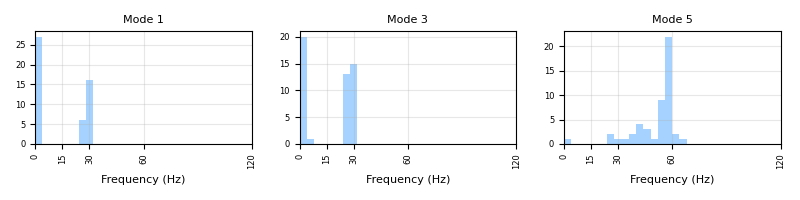

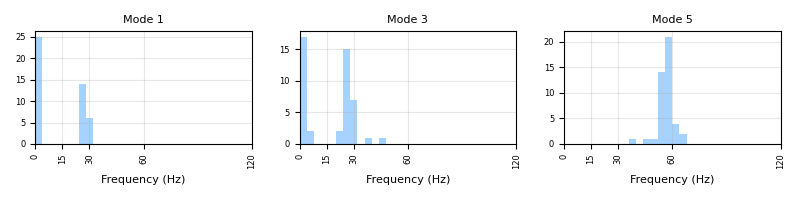

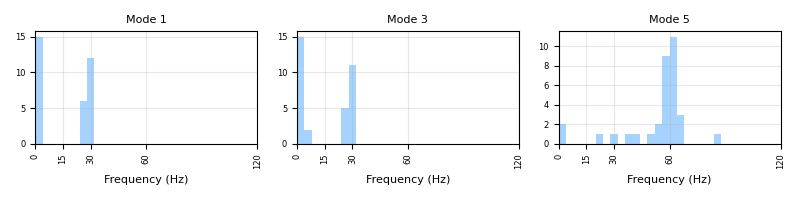

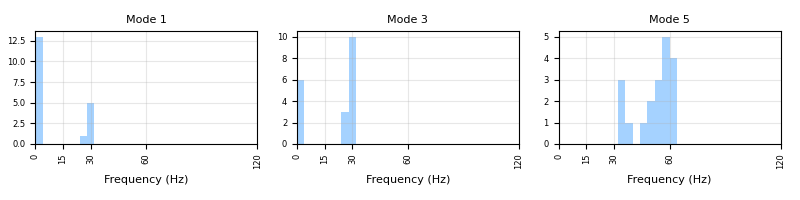

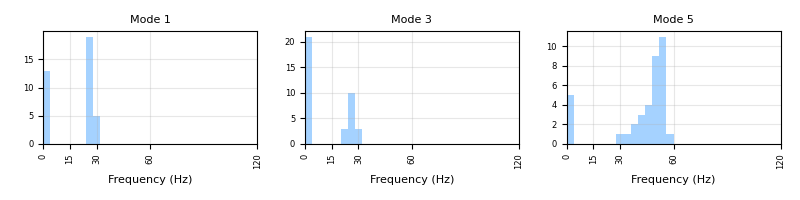

In [228]:
aggregateDMD.plot_dmd_histograms(DMD_results_12m6Modes, modes=[0, 2, 4])
aggregateDMD.plot_dmd_histograms(DMD_results_Init12m6Modes, modes=[0, 2, 4])
aggregateDMD.plot_dmd_histograms(DMD_results_Ru12m6Modes, modes=[0, 2, 4])
aggregateDMD.plot_dmd_histograms(DMD_results_Dr12m6Modes, modes=[0, 2, 4])
aggregateDMD.plot_dmd_histograms(DMD_results_Ch12m6Modes, modes=[0, 2, 4])



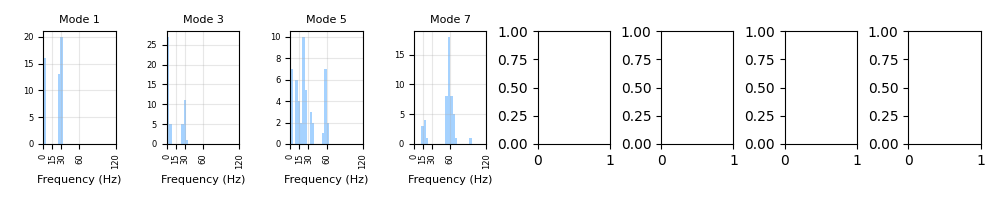

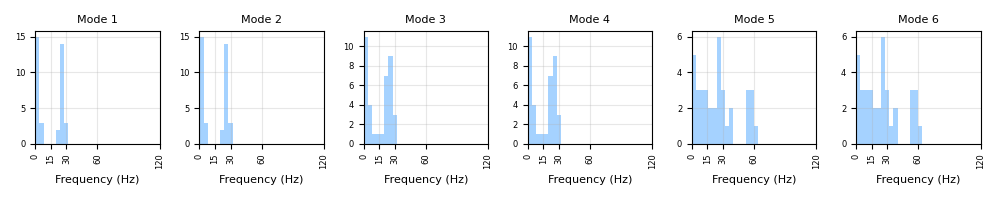

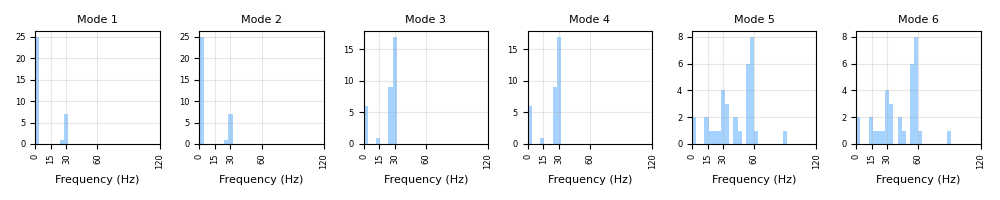

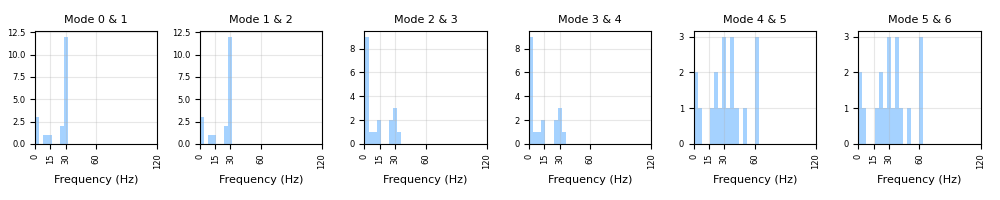

In [212]:
fig, axes = plt.subplots(1, 8, figsize=(10, 2), sharey=False, tight_layout=True)
counter = 0
for ii in range(0,8,2):
    lambda_i_values = DMD_results_12m6Modes['Lambda'].apply(lambda x: x[ii])
    axes[counter].hist(abs(lambda_i_values), bins=50, alpha=0.4, color='dodgerblue', range=(0, 200))


    axes[counter].set_xticks([0, 15, 30, 60, 120])
    axes[counter].set_xlim(0, 120)
    axes[counter].grid(alpha=0.3)
    axes[counter].tick_params(axis='x', which='major', labelsize=6, rotation=90)
    axes[counter].tick_params(axis='y', which='major', labelsize=6)
    axes[counter].set_title(f"Mode {ii+1}", fontsize=8)
    axes[counter].set_xlabel("Frequency (Hz)", fontsize=8)

    counter = counter + 1

fig, axes = plt.subplots(1, 6, figsize=(10, 2), sharey=False, tight_layout=True)
counter = 0
for ii in range(0,6):
    lambda_i_values = DMD_results_Ch12m6Modes['Lambda'].apply(lambda x: x[ii])
    axes[counter].hist(abs(lambda_i_values), bins=50, alpha=0.4, color='dodgerblue', range=(0, 200))


    axes[counter].set_xticks([0, 15, 30, 60, 120])
    axes[counter].set_xlim(0, 120)
    axes[counter].grid(alpha=0.3)
    axes[counter].tick_params(axis='x', which='major', labelsize=6, rotation=90)
    axes[counter].tick_params(axis='y', which='major', labelsize=6)
    axes[counter].set_title(f"Mode {ii+1}", fontsize=8)
    axes[counter].set_xlabel("Frequency (Hz)", fontsize=8)

    counter = counter + 1

fig, axes = plt.subplots(1, 6, figsize=(10, 2), sharey=False, tight_layout=True)
counter = 0
for ii in range(0,6):
    lambda_i_values = DMD_results_Ru12m6Modes['Lambda'].apply(lambda x: x[ii])
    axes[counter].hist(abs(lambda_i_values), bins=50, alpha=0.4, color='dodgerblue', range=(0, 200))

    axes[counter].set_xticks([0, 15, 30, 60, 120])
    axes[counter].set_xlim(0, 120)
    axes[counter].grid(alpha=0.3)
    axes[counter].tick_params(axis='x', which='major', labelsize=6, rotation=90)
    axes[counter].tick_params(axis='y', which='major', labelsize=6)
    axes[counter].set_title(f"Mode {ii+1}", fontsize=8)
    axes[counter].set_xlabel("Frequency (Hz)", fontsize=8)

    counter = counter + 1

fig, axes = plt.subplots(1, 6, figsize=(10, 2), sharey=False, tight_layout=True)
counter = 0
for ii in range(0,6):
    lambda_i_values = DMD_results_Dr12m6Modes['Lambda'].apply(lambda x: x[ii])
    axes[counter].hist(abs(lambda_i_values), bins=50, alpha=0.4, color='dodgerblue', range=(0, 200))


    axes[counter].set_xticks([0, 15, 30, 60, 120])
    axes[counter].set_xlim(0, 120)
    axes[counter].grid(alpha=0.3)
    axes[counter].tick_params(axis='x', which='major', labelsize=6, rotation=90)
    axes[counter].tick_params(axis='y', which='major', labelsize=6)
    axes[counter].set_title(f"Mode {ii} & {ii+1}", fontsize=8)
    axes[counter].set_xlabel("Frequency (Hz)", fontsize=8)

    counter = counter + 1





    

## Running Many DMDs

In [4]:

def load_sequence_data(df, seqID, marker_column_names):
    """Load markers and time data for a given sequence ID."""
    condition = df['seqID'] == seqID
    markers = df[condition][marker_column_names].to_numpy().astype(np.float64)
    times = df[condition]['time'].to_numpy().astype(np.float64)
    return markers, times

def normalise_data(markers, average_shape):
    """Normalise marker data by subtracting the average shape."""
    return markers - average_shape, average_shape

def perform_dmd(markers, times, n_Modes):
    """Perform Dynamic Mode Decomposition on the marker data."""
    markers = markers.T  # Transpose data
    dmd_processor = hankel_preprocessing(BOPDMD(svd_rank=n_Modes, 
                                                eig_constraints={"imag", "conjugate_pairs"}), 
                                                d=2)
    
    dmd_processor.fit(markers, t=times[1:])
    forecast = dmd_processor.forecast(times)
    return dmd_processor, forecast

def run_forecast(forecast, average_shape, num_markers):
    """Run the forecast to get the predicted markers."""
    forecast = np.real(forecast[:num_markers*3,:])
    forecast_plus_mean = forecast.T + average_shape

    keypoints = forecast_plus_mean.reshape(-1, num_markers, 3)

    # Take away the first frame and add an extra frame to the end
    keypoints = np.concatenate([keypoints[1:], keypoints[-1:]], axis=0)

    return keypoints

def reorder_dmd_results(dmd_results, num_markers, nModes):
    """Reorder DMD results based on amplitude size and extract components."""
    bn = np.argsort(dmd_results.amplitudes)[::-1]
    Psi = dmd_results.modes
    Psi = Psi[:num_markers*3, bn]
    
    Lambda = np.imag(dmd_results.eigs)[bn]
    Modes = np.real(Psi).reshape(num_markers, 3, nModes)

    return Lambda, Modes, dmd_results.amplitudes[bn], Psi

def save_results_npz(save_path, seqID, times, markers, Lambda, Modes, bn, Psi, keypoints):
    """Save DMD results to a single .npz file for a given sequence ID."""
    np.savez_compressed(f"{save_path}{seqID}_dmd_results.npz", 
                        times = times,
                        markers = markers,
                        Lambda=Lambda, 
                        Modes=Modes, 
                        bn=bn, 
                        Psi=Psi, 
                        forecast_keypoints=keypoints)

def load_results_npz(save_path, seqID):
    """Load DMD results for a specific sequence ID from a .npz file."""
    try:
        data = np.load(f"{save_path}{seqID}_dmd_results.npz")
    except FileNotFoundError:
        print(f"File {save_path}{seqID}_dmd_results.npz not found.")
        return None, None, None, None, None
    
    times = data['times']
    markers = data['markers']
    Lambda = data['Lambda']
    Modes = data['Modes']
    bn = data['bn']
    Psi = data['Psi']
    keypoints = data['forecast_keypoints']
    
    return times, markers, Lambda, Modes, bn, Psi, keypoints


# --- Main script ---

def process_and_store_sequences(df, nModes, marker_column_names, average_shape, save_path):
    """Process and store DMD results for all sequences in the DataFrame."""
    num_markers = 8

    for seqID in df['seqID'].unique():

        markers, times = load_sequence_data(df, seqID, marker_column_names)

        if markers.shape[0] <= nModes+1:
            print(f"Skipping sequence {seqID} due to insufficient timesteps.")
            continue

        normalised_markers, _ = normalise_data(markers, average_shape)
        dmd_results, forecast = perform_dmd(normalised_markers, times, nModes)
        Lambda, Modes, bn, Psi = reorder_dmd_results(dmd_results, num_markers, nModes)
        keypoints = run_forecast(forecast, average_shape, num_markers)
        markers = markers.reshape(-1, num_markers, 3)
        save_results_npz(save_path, seqID, times, markers, Lambda, Modes, bn, Psi, keypoints)



## Run on Flights

In [46]:

hawk_name = "Toothless"

wingbeat_df, marker_column_names = runDMD.load_bird_data(hawk_name, perch_distance = "12m", bilateral=bilateral)
wingbeat_df = runDMD.remove_time_duplicates(wingbeat_df)
seqList = wingbeat_df['seqID'].unique()
markers, times = runDMD.load_sequence_data(wingbeat_df, seqList[4], marker_column_names)

average_shape, num_markers = runDMD.get_average_shape(markers)
normalised_markers, _ = runDMD.normalise_data(markers, average_shape)


nModes = 6
dmd_results, forecast = runDMD.perform_dmd(normalised_markers, times, nModes)
Lambda, Modes, bn, Psi = runDMD.reorder_dmd_results(dmd_results, num_markers, nModes)

keypoints = runDMD.run_forecast(forecast, average_shape, num_markers)

markers = markers.reshape(-1, num_markers, 3)



Loading Toothless bilateral data with 12m perch distances.
Dataframe with shape (4060, 38) loaded. Number of sequences: 175
Duplicated frames are 10.0% of the total data.
[ -0.119   0.119 -33.561  33.561 -59.58   59.58 ]


Figure and axes initialized.


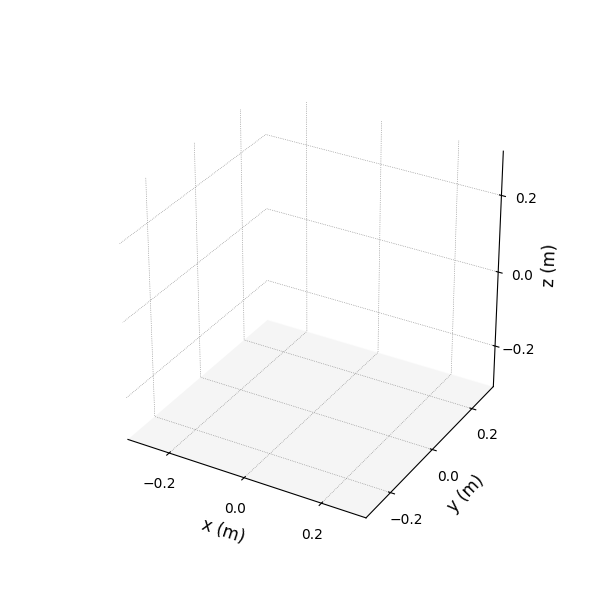

In [45]:
hawk3d = Hawk3D("../data/mean_hawk_shape.csv")
animate_compare(hawk3d, keypoints_frames_list=[markers, keypoints])


In [47]:
plt.close()

In [21]:

import warnings
warnings.filterwarnings("ignore")

hawk_name = "Ruby"
# perch_distance = "9m"
# turn = "Left"
wingbeat_df, marker_column_names = load_bird_data(hawk_name, bilateral=bilateral)

wingbeat_df = handle_duplicates(wingbeat_df)

hawk3d = Hawk3D("../data/mean_hawk_shape.csv")
average_shape = hawk3d.markers.reshape(24,1).T
nModes = 6

save_path = f"../data/2024-06-12_All{hawk_name}_DMD_results/{str(nModes)}Modes/"

# Print the number of sequences
print(f"Processing {wingbeat_df['seqID'].nunique()} sequences with {nModes} modes.")
process_and_store_sequences(wingbeat_df, nModes, marker_column_names, average_shape, save_path)



Dataframe with shape (2374, 38) loaded. Number of sequences: 150
Duplicated frames are 2.53% of the total data.
Processing 150 sequences with 6 modes.
Skipping sequence 03_05_002 due to insufficient timesteps.
Skipping sequence 03_05_005 due to insufficient timesteps.
Skipping sequence 03_05_007 due to insufficient timesteps.
Skipping sequence 03_05_009 due to insufficient timesteps.
Skipping sequence 03_05_014 due to insufficient timesteps.
Skipping sequence 03_05_022 due to insufficient timesteps.
Skipping sequence 03_05_028 due to insufficient timesteps.
Skipping sequence 03_05_030 due to insufficient timesteps.
Skipping sequence 03_05_032 due to insufficient timesteps.
Skipping sequence 03_05_034 due to insufficient timesteps.
Skipping sequence 03_05_205 due to insufficient timesteps.
Skipping sequence 03_05_217 due to insufficient timesteps.
Skipping sequence 03_07_082 due to insufficient timesteps.
Skipping sequence 03_07_084 due to insufficient timesteps.
Skipping sequence 03_07

# Statistics on Multiple Wingbeat Examples

In [50]:
import os

def load_dmd_results(wingbeat_df, save_path):

    # Initialize list to store data dictionaries
    DMD_dict = []

    # For each .npz file in the directory, load the numpy arrays inside and stack them
    for seqID in wingbeat_df['seqID'].unique():
        # Check if the file exists
        if not os.path.exists(f"{save_path}{seqID}_dmd_results.npz"):
            continue

        times, markers, Lambda, Modes, bn, Psi, keypoints = load_results_npz(save_path, seqID)

        if times is None:
            continue

        # Append a dictionary of the data to the list
        DMD_dict.append({
            "seqID": seqID,
            "times": times,
            "markers": markers,
            "Lambda": Lambda,
            "Modes": Modes,
            "bn": bn,
            "Psi": Psi,
            "keypoints": keypoints
        })

        

    # Convert the list of dictionaries to a DataFrame
    return pd.DataFrame(DMD_dict)


# Load results from 12 modes
nModes = 12
save_path = f"../data/2024-06-12_12mToothless_DMD_results/{str(nModes)}Modes/"
DMD_results_6Modes = load_dmd_results(wingbeat_df,save_path)


print(DMD_results_12Modes.head())



Empty DataFrame
Columns: []
Index: []


In [ ]:

# # Load results from 8 modes
# nModes = 10
# save_path = f"../data/2024-06-12_12mToothless_DMD_results/{str(nModes)}Modes/"
# DMD_results_10Modes = load_dmd_results(wingbeat_df,save_path)



# # Load results from 8 modes
# nModes = 8
# save_path = f"../data/2024-06-12_12mToothless_DMD_results/{str(nModes)}Modes/"
# DMD_results_8Modes = load_dmd_results(wingbeat_df,save_path)

# # Load results from 8 modes
# nModes = 7
# save_path = f"../data/2024-06-12_12mToothless_DMD_results/{str(nModes)}Modes/"
# DMD_results_7Modes = load_dmd_results(wingbeat_df,save_path)


# # Load results from 8 modes
# nModes = 6
# save_path = f"../data/2024-06-12_12mToothless_DMD_results/{str(nModes)}Modes/"
# DMD_results_6Modes = load_dmd_results(wingbeat_df,save_path)


# # Load results from 6 modes
# hawkname = "Toothless"
# perch_distance = "5m"
# bilateral = True
# wingbeat_df, marker_column_names = load_bird_data(hawkname, perch_distance, bilateral)

# nModes = 6
# save_path = f"../data/2024-06-12_{perch_distance}{hawkname}_DMD_results/{str(nModes)}Modes/"
# DMD_results_To5m = load_dmd_results(wingbeat_df,save_path)


# # # Load results from 6 modes
# hawkname = "Toothless"
# perch_distance = "7m"
# bilateral = True
# wingbeat_df, marker_column_names = load_bird_data(hawkname, perch_distance, bilateral)

# nModes = 6
# save_path = f"../data/2024-06-12_{perch_distance}{hawkname}_DMD_results/{str(nModes)}Modes/"
# DMD_results_To7m = load_dmd_results(wingbeat_df,save_path)


# # # Load results from 6 modes
# hawkname = "Toothless"
# perch_distance = "9m"
# bilateral = True
# wingbeat_df, marker_column_names = load_bird_data(hawkname, perch_distance, bilateral)

# nModes = 6
# save_path = f"../data/2024-06-12_{perch_distance}{hawkname}_DMD_results/{str(nModes)}Modes/"
# DMD_results_To9m = load_dmd_results(wingbeat_df,save_path)




# # # Load results from 6 modes
# hawkname = "Toothless"
# perch_distance = "12m"
# bilateral = True
# wingbeat_df, marker_column_names = load_bird_data(hawkname, perch_distance, bilateral)

# nModes = 6
# save_path = f"../data/2024-06-12_{perch_distance}{hawkname}_DMD_results/{str(nModes)}Modes/"
# DMD_results_To12m = load_dmd_results(wingbeat_df,save_path)


# # # Load results from 6 modes
# hawkname = "Toothless"
# perch_distance = "9m"
# bilateral = True
# turn = "Straight"
# wingbeat_df, marker_column_names = load_bird_data(hawkname, perch_distance, bilateral, turn)

# nModes = 6
# save_path = f"../data/2024-06-12_{perch_distance}{turn}{hawkname}_DMD_results/{str(nModes)}Modes/"
# DMD_results_To9mStraight = load_dmd_results(wingbeat_df,save_path)

# # # Load results from 6 modes
# hawkname = "Toothless"
# perch_distance = "9m"
# bilateral = True
# turn = "Right"
# wingbeat_df, marker_column_names = load_bird_data(hawkname, perch_distance, bilateral, turn)

# nModes = 6
# save_path = f"../data/2024-06-12_{perch_distance}{turn}{hawkname}_DMD_results/{str(nModes)}Modes/"
# DMD_results_To9mRight = load_dmd_results(wingbeat_df,save_path)

# # # Load results from 6 modes
# hawkname = "Toothless"
# perch_distance = "9m"
# bilateral = True
# turn = "Left"
# wingbeat_df, marker_column_names = load_bird_data(hawkname, perch_distance, bilateral, turn)

# nModes = 6
# save_path = f"../data/2024-06-12_{perch_distance}{turn}{hawkname}_DMD_results/{str(nModes)}Modes/"
# DMD_results_To9mLeft = load_dmd_results(wingbeat_df,save_path)


# # # Load results from 6 modes
# hawkname = "Toothless"
# perch_distance = "9m"
# bilateral = True
# turn = "Left"
# wingbeat_df, marker_column_names = load_bird_data(hawkname, perch_distance, bilateral, turn)

# nModes = 6
# save_path = f"../data/2024-06-12_{perch_distance}{turn}{hawkname}_DMD_results/{str(nModes)}Modes/"
# DMD_results_To9mLeft = load_dmd_results(wingbeat_df,save_path)




# # # Load results from 6 modes
# hawkname = "Drogon"
# # perch_distance = "9m"
# bilateral = True
# wingbeat_df, marker_column_names = load_bird_data(hawkname, bilateral=bilateral)

# nModes = 6
# save_path = f"../data/2024-06-12_All{hawkname}_DMD_results/{str(nModes)}Modes/"
# DMD_results_Dr = load_dmd_results(wingbeat_df,save_path)

# # # Load results from 6 modes
# hawkname = "Rhaegal"
# # perch_distance = "9m"
# bilateral = True
# wingbeat_df, marker_column_names = load_bird_data(hawkname, bilateral=bilateral)

# nModes = 6
# save_path = f"../data/2024-06-12_All{hawkname}_DMD_results/{str(nModes)}Modes/"
# DMD_results_Rh = load_dmd_results(wingbeat_df,save_path)


# # # Load results from 6 modes
# hawkname = "Ruby"
# # perch_distance = "9m"
# bilateral = True
# wingbeat_df, marker_column_names = load_bird_data(hawkname, bilateral=bilateral)

# nModes = 6
# save_path = f"../data/2024-06-12_All{hawkname}_DMD_results/{str(nModes)}Modes/"
# DMD_results_Ru = load_dmd_results(wingbeat_df,save_path)


# # # Load results from 6 modes
# hawkname = "Toothless"
# # perch_distance = "9m"
# bilateral = True
# wingbeat_df, marker_column_names = load_bird_data(hawkname, bilateral=bilateral)

# nModes = 6
# save_path = f"../data/2024-06-12_All{hawkname}_DMD_results/{str(nModes)}Modes/"
# DMD_results_To = load_dmd_results(wingbeat_df,save_path)



# # # Load results from 6 modes
# hawkname = "Charmander"
# # perch_distance = "9m"
# bilateral = True
# wingbeat_df, marker_column_names = load_bird_data(hawkname, bilateral=bilateral)

# nModes = 6
# save_path = f"../data/2024-06-12_All{hawkname}_DMD_results/{str(nModes)}Modes/"
DMD_results_Ch = load_dmd_results(wingbeat_df,save_path)







## Histogram of each lamda (frequency)

,seqID,times,markers,Lambda,Modes,bn,Psi,keypoints
0,04_12_101,"[-0.03, -0.025, -0.02, -0.015, -0.01, -0.005, ...","[[[-0.172038850054771, -0.0162966482359841, -0...","[-32.19064145151294, 32.19064145151294, -15.40...","[[[0.11435494658668609, 0.11435494658668618, 0...","[0.5370600184589004, 0.5370600184589004, 0.258...","[[(0.11435494658668609-0.025353684784724655j),...","[[[-0.11455066536245909, -0.003109857041089056..."
1,04_12_102,"[-0.03, -0.025, -0.02, -0.015, -0.01, -0.00499...","[[[-0.140639753456437, -0.0253636588381462, -0...","[-35.55326685277435, 35.55326685277435, 13.547...","[[[0.09227392150969267, 0.09227392150969262, 0...","[0.5547467463013538, 0.5547467463013532, 0.271...","[[(0.09227392150969267-0.0635492628129514j), (...","[[[-0.1773425545169431, -0.036627626899384036,..."
2,04_12_103,"[-0.0249999999999999, -0.0199999999999999, -0....","[[[-0.324280648603502, -0.0351412413119354, -0...","[-31.618413337536285, 31.618413337536285, 0.0,...","[[[0.04301592656164872, 0.04301592656164828, -...","[0.5982428555747753, 0.5982428555747753, 0.116...","[[(0.04301592656164872+0.13251381384448394j), ...","[[[-0.36425706381366163, 0.014259875155454613,..."
3,04_12_104,"[-0.03, -0.0249999999999999, -0.02, -0.0149999...","[[[-0.162751843896338, -0.0228670755034021, -0...","[-25.397492647860854, 25.397492647860854, 14.8...","[[[0.06524274255834792, 0.06524274255834808, 0...","[0.660560286849417, 0.6605602868494167, 0.4621...","[[(0.06524274255834792-0.11517832540713727j), ...","[[[-0.11311747071534423, -0.010407490252413165..."
4,04_12_105,"[-0.03, -0.025, -0.02, 0.0, 0.0049999999999999...","[[[-0.101714020258886, -0.0361329013960749, -0...","[-33.14708634164968, 33.14708634164968, -8.216...","[[[0.11746148288798768, 0.11746148288798763, 0...","[0.5468692538620925, 0.5468692538620923, 0.231...","[[(0.11746148288798768+0.017968928727183246j),...","[[[-0.1057780298471516, -0.007736416504710256,..."


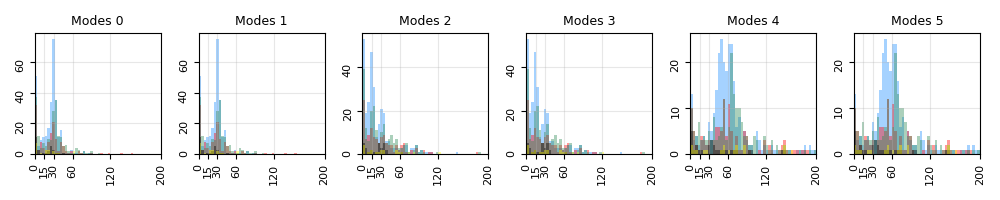

In [36]:

# Create a figure with 12 subplots (1 row, 12 columns)
fig, axes = plt.subplots(1, 6, figsize=(10, 2), sharey=False, tight_layout=True)

# Plot each Lambda value in its own subplot
counter = 0
for ii in range(0,6):
    lambda_i_values = DMD_results_To['Lambda'].apply(lambda x: x[ii])
    axes[counter].hist(abs(lambda_i_values), bins=50, alpha=0.4, color='dodgerblue', range=(0, 200))

    lambda_i_values = DMD_results_Rh['Lambda'].apply(lambda x: x[ii])
    axes[counter].hist(abs(lambda_i_values), bins=50, alpha=0.4, color='red', range=(0, 200))

    lambda_i_values = DMD_results_Dr['Lambda'].apply(lambda x: x[ii])
    axes[counter].hist(abs(lambda_i_values), bins=50, alpha=0.4, color='seagreen', range=(0, 200))

    lambda_i_values = DMD_results_To9mRight['Lambda'].apply(lambda x: x[ii])
    axes[counter].hist(abs(lambda_i_values), bins=50, alpha=0.4, color='black', range=(0, 200))

    lambda_i_values = DMD_results_To9mLeft['Lambda'].apply(lambda x: x[ii])
    axes[counter].hist(abs(lambda_i_values), bins=50, alpha=0.4, color='yellow', range=(0, 200))
    

    # lambda_i_values = DMD_results_Ru['Lambda'].apply(lambda x: x[ii])
    # axes[counter].hist(abs(lambda_i_values), bins=50, alpha=0.4, color='purple')

    # lambda_i_values = DMD_results_Ch['Lambda'].apply(lambda x: x[ii])
    # axes[counter].hist(abs(lambda_i_values), bins=50, alpha=0.4, color='black')


    axes[counter].set_xlim(0, 200)

    # Make sure 25 and 50 are visible on the x-axis
    axes[counter].set_xticks([0, 15, 30, 60, 120, 200])
    axes[counter].grid(alpha=0.3)
    axes[counter].tick_params(axis='both', which='major', labelsize=6, rotation=90)

    
        

    axes[counter].tick_params(axis='both', which='major', labelsize=8)
    axes[counter].set_title(f"Modes {ii}", fontsize=9)

    counter += 1

# Adjust layout to prevent overlap
plt.tight_layout()
plt.subplots_adjust(wspace=0.3)
# fig.suptitle('Lambda for Single Wingbeat', fontsize=16)

plt.show()

KeyError: 'Lambda'

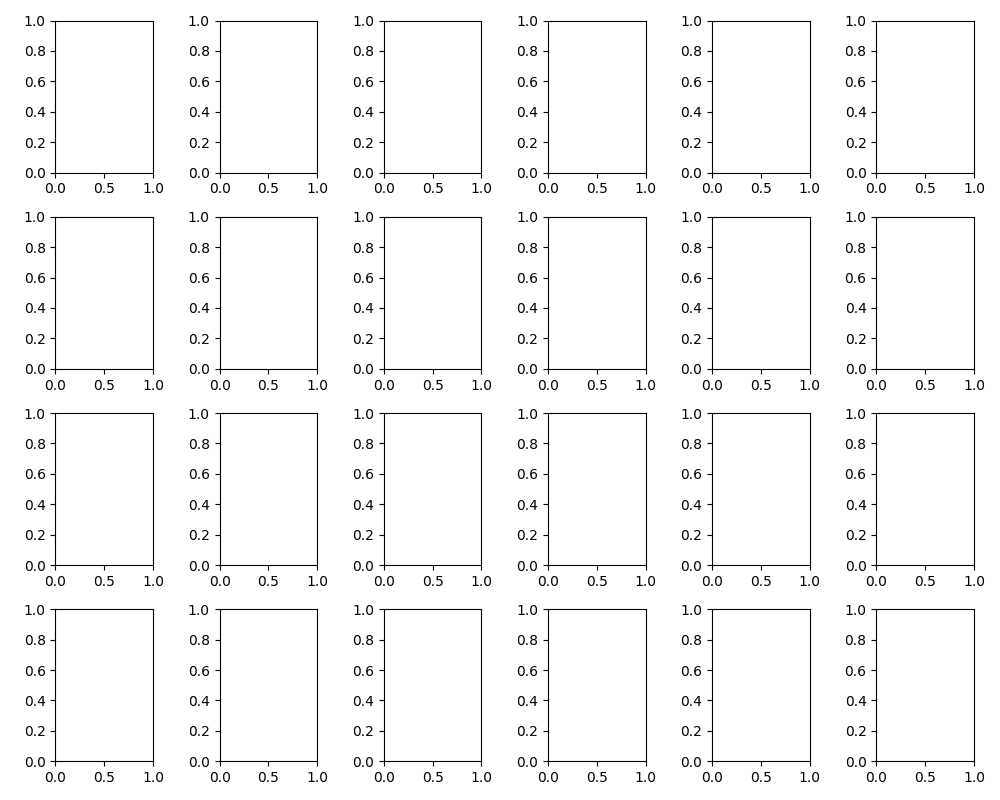

In [45]:

# Define the number of modes for each row
modes = [12, 10, 8, 6]

# Create a figure with 18 subplots (3 rows, 6 columns)
fig, axes = plt.subplots(4, 6, figsize=(10, 8), sharey=False, tight_layout=True)

# Plot each Lambda value in its own subplot for each mode set
for row, nModes in enumerate(modes):
    if nModes == 12:
        DMD_results = DMD_results_12Modes
    elif nModes == 8:
        DMD_results = DMD_results_8Modes
    elif nModes == 6:
        DMD_results = DMD_results_6Modes 
    
    counter = 0
    for ii in range(0, 12, 2):
        if counter >= nModes // 2:
            break
        lambda_i_values = DMD_results['Lambda'].apply(lambda x: x[ii])
        axes[row, counter].hist(abs(lambda_i_values), bins=100, alpha=0.2, color='dodgerblue')

        lambda_i_values = DMD_results['Lambda'].apply(lambda x: x[ii+1])
        axes[row, counter].hist(abs(lambda_i_values), bins=100, alpha=0.2, color='seagreen')

        axes[row, counter].tick_params(axis='both', which='major', labelsize=6, rotation=90)
        axes[row, counter].set_title(f"Modes {ii+1} & {ii+2}", fontsize=9)
        axes[row, counter].grid(True)

        # make grid more trasparent
        axes[row, counter].grid(alpha=0.3)

        # Make sure 25 and 50 are visible on the x-axis
        axes[row, counter].set_xticks([0, 15, 30, 60, 120, 200, 300])
        
        # axes[row, counter].set_xlim([0, 200])
        
        counter += 1
    
    # first column subplots ax xlim is set to 0, 100
    axes[row, 0].set_xlim([0, 100])
    axes[row, 1].set_xlim([0, 100])
    axes[row, 2].set_xlim([0, 200])
    axes[row, 3].set_xlim([0, 200])
    axes[row, 4].set_xlim([0, 300])
    axes[row, 5].set_xlim([0, 300])
    
    # Axis off for any remaining subplots
    for jj in range(counter, 6):
        axes[row, jj].axis('off')

    

# Set titles for the rows
axes[0, 0].set_ylabel('12 Modes', fontsize=12)
axes[1, 0].set_ylabel('10 Modes', fontsize=12)
axes[2, 0].set_ylabel('8 Modes', fontsize=12)
axes[3, 0].set_ylabel('6 Modes', fontsize=12)

# Adjust layout to prevent overlap
plt.tight_layout()
plt.subplots_adjust(wspace=0.3, hspace=0.5)
# fig.suptitle('Lambda for Single Wingbeat', fontsize=16)

plt.show()

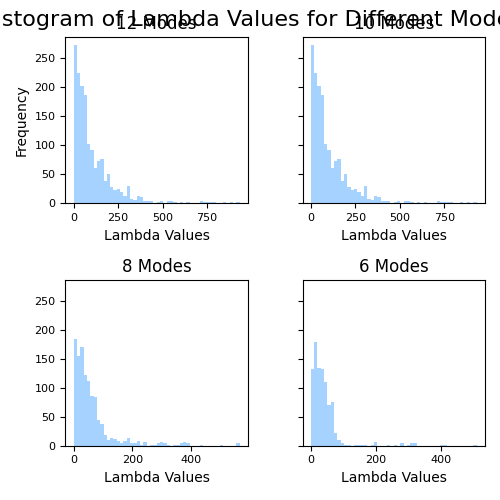

In [94]:

# Define the number of modes for each row
modes = [12, 10, 8, 6]

# Create a figure with 3 subplots (1 row, 3 columns)
fig, axes = plt.subplots(2, 2, figsize=(5, 5), sharey=True, tight_layout=True)
axes = axes.flatten()
# Plot a histogram of all Lambda values for each mode set
for idx, nModes in enumerate(modes):
    if nModes == 12:
        DMD_results = DMD_results_12Modes
    elif nModes == 8:
        DMD_results = DMD_results_8Modes
    elif nModes == 6:
        DMD_results = DMD_results_6Modes
    
    # Combine all Lambda values into a single array
    lambda_values = np.concatenate(DMD_results['Lambda'].values)
    
    # Plot the histogram
    axes[idx].hist(abs(lambda_values), bins=50, alpha=0.4, color='dodgerblue')
    axes[idx].tick_params(axis='both', which='major', labelsize=8)
    axes[idx].set_title(f"{nModes} Modes", fontsize=12)
    axes[idx].set_xlabel('Lambda Values')

axes[0].set_ylabel('Frequency')

# Adjust layout to prevent overlap
plt.tight_layout()
plt.subplots_adjust(wspace=0.3)
fig.suptitle('Histogram of Lambda Values for Different Modes', fontsize=16)

plt.show()


In [83]:
nModes = 8
save_path = f"../data/2024-06-12_Toothless_DMD_results/{str(nModes)}Modes/"

seqID_list = wingbeat_df['seqID'].unique()

times, markers, Lambda, Modes, bn, Psi, keypoints = load_results_npz(save_path, seqID_list[0])

print(Lambda)

[ 48.193 -48.193  41.037 -41.037  54.503 -54.503   3.308  -3.308]


In [18]:
Modes.shape

(8, 3, 10)

Figure and axes initialized.


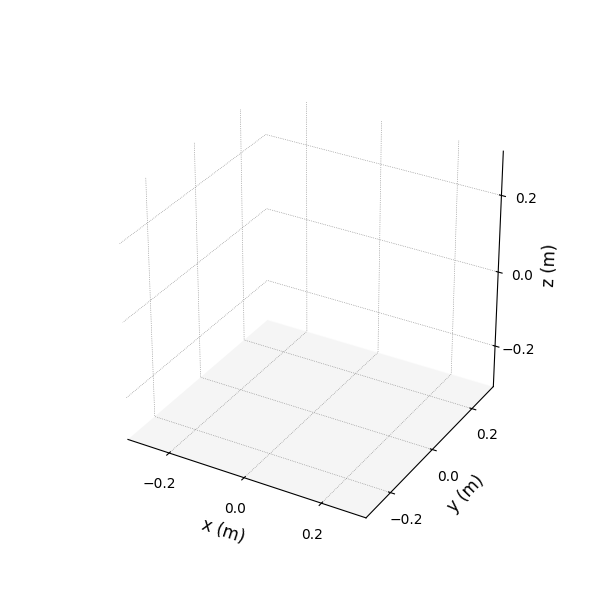

In [24]:
hawk3d = Hawk3D("../data/mean_hawk_shape.csv")
currentMode = Modes[:,:,0]
currentMode = currentMode.reshape(1,8,3)
animation = animate(hawk3d,currentMode)


In [20]:
hawk3d = Hawk3D("../data/mean_hawk_shape.csv")
animate_compare(hawk3d, keypoints_frames_list=[markers, keypoints])
plt.close()

Figure and axes initialized.


/Users/lfrance/Library/CloudStorage/OneDrive-TheAlanTuringInstitute/002_Projects/Hawkflight/BirdDMD/venv/lib/python3.12/site-packages/matplotlib/animation.py:892: UserWarning: Animation was deleted without rendering anything. This is most likely not intended. To prevent deletion, assign the Animation to a variable, e.g. `anim`, that exists until you output the Animation using `plt.show()` or `anim.save()`.
  warnings.warn(


## Save Toothless 5m Flights

In [52]:
wingbeat_df, marker_column_names = load_bird_data("Toothless", "5m", bilateral)

wingbeat_df = handle_duplicates(wingbeat_df)

hawk3d = Hawk3D("../data/mean_hawk_shape.csv")
average_shape = hawk3d.markers.reshape(24,1).T
save_path = "../data/2024-05-15_DMD_results/04_05/"

process_and_store_sequences(wingbeat_df, marker_column_names, average_shape, save_path)



Dataframe with shape (710, 37) loaded. Number of sequences: 40
Duplicated frames are 7.61% of the total data.
Skipping sequence 04_05_080 due to insufficient timesteps.
Skipping sequence 04_05_097 due to insufficient timesteps.


/Users/lfrance/Library/CloudStorage/OneDrive-TheAlanTuringInstitute/002_Projects/Hawkflight/BirdDMD/venv/lib/python3.12/site-packages/pydmd/bopdmd.py:751: UserWarning: Initial trial of Optimized DMD failed to converge. Consider re-adjusting your variable projection parameters with the varpro_opts_dict and consider setting verbose=True.
  warnings.warn(msg)
/Users/lfrance/Library/CloudStorage/OneDrive-TheAlanTuringInstitute/002_Projects/Hawkflight/BirdDMD/venv/lib/python3.12/site-packages/pydmd/bopdmd.py:751: UserWarning: Initial trial of Optimized DMD failed to converge. Consider re-adjusting your variable projection parameters with the varpro_opts_dict and consider setting verbose=True.
  warnings.warn(msg)
/Users/lfrance/Library/CloudStorage/OneDrive-TheAlanTuringInstitute/002_Projects/Hawkflight/BirdDMD/venv/lib/python3.12/site-packages/pydmd/bopdmd.py:751: UserWarning: Initial trial of Optimized DMD failed to converge. Consider re-adjusting your variable projection parameters with 

Skipping sequence 04_05_108 due to insufficient timesteps.


/Users/lfrance/Library/CloudStorage/OneDrive-TheAlanTuringInstitute/002_Projects/Hawkflight/BirdDMD/venv/lib/python3.12/site-packages/pydmd/bopdmd.py:751: UserWarning: Initial trial of Optimized DMD failed to converge. Consider re-adjusting your variable projection parameters with the varpro_opts_dict and consider setting verbose=True.
  warnings.warn(msg)
/Users/lfrance/Library/CloudStorage/OneDrive-TheAlanTuringInstitute/002_Projects/Hawkflight/BirdDMD/venv/lib/python3.12/site-packages/pydmd/bopdmd.py:751: UserWarning: Initial trial of Optimized DMD failed to converge. Consider re-adjusting your variable projection parameters with the varpro_opts_dict and consider setting verbose=True.
  warnings.warn(msg)
/Users/lfrance/Library/CloudStorage/OneDrive-TheAlanTuringInstitute/002_Projects/Hawkflight/BirdDMD/venv/lib/python3.12/site-packages/pydmd/bopdmd.py:751: UserWarning: Initial trial of Optimized DMD failed to converge. Consider re-adjusting your variable projection parameters with 

Skipping sequence 04_05_113 due to insufficient timesteps.
Skipping sequence 04_05_119 due to insufficient timesteps.
Skipping sequence 04_05_231 due to insufficient timesteps.


...

/Users/lfrance/Library/CloudStorage/OneDrive-TheAlanTuringInstitute/002_Projects/Hawkflight/BirdDMD/venv/lib/python3.12/site-packages/pydmd/bopdmd.py:751: UserWarning: Initial trial of Optimized DMD failed to converge. Consider re-adjusting your variable projection parameters with the varpro_opts_dict and consider setting verbose=True.
  warnings.warn(msg)
/Users/lfrance/Library/CloudStorage/OneDrive-TheAlanTuringInstitute/002_Projects/Hawkflight/BirdDMD/venv/lib/python3.12/site-packages/pydmd/bopdmd.py:751: UserWarning: Initial trial of Optimized DMD failed to converge. Consider re-adjusting your variable projection parameters with the varpro_opts_dict and consider setting verbose=True.
  warnings.warn(msg)
/Users/lfrance/Library/CloudStorage/OneDrive-TheAlanTuringInstitute/002_Projects/Hawkflight/BirdDMD/venv/lib/python3.12/site-packages/pydmd/bopdmd.py:751: UserWarning: Initial trial of Optimized DMD failed to converge. Consider re-adjusting your variable projection parameters with 

Skipping sequence 04_05_248 due to insufficient timesteps.
Skipping sequence 04_05_250 due to insufficient timesteps.
Skipping sequence 04_05_255 due to insufficient timesteps.
Skipping sequence 04_05_258 due to insufficient timesteps.
Skipping sequence 04_05_264 due to insufficient timesteps.
Skipping sequence 04_05_265 due to insufficient timesteps.
Skipping sequence 04_05_322 due to insufficient timesteps.


/Users/lfrance/Library/CloudStorage/OneDrive-TheAlanTuringInstitute/002_Projects/Hawkflight/BirdDMD/venv/lib/python3.12/site-packages/pydmd/bopdmd.py:751: UserWarning: Initial trial of Optimized DMD failed to converge. Consider re-adjusting your variable projection parameters with the varpro_opts_dict and consider setting verbose=True.
  warnings.warn(msg)
/Users/lfrance/Library/CloudStorage/OneDrive-TheAlanTuringInstitute/002_Projects/Hawkflight/BirdDMD/venv/lib/python3.12/site-packages/pydmd/bopdmd.py:751: UserWarning: Initial trial of Optimized DMD failed to converge. Consider re-adjusting your variable projection parameters with the varpro_opts_dict and consider setting verbose=True.
  warnings.warn(msg)


Skipping sequence 04_05_332 due to insufficient timesteps.
Skipping sequence 04_05_338 due to insufficient timesteps.
Skipping sequence 04_05_342 due to insufficient timesteps.
Skipping sequence 04_05_345 due to insufficient timesteps.


/Users/lfrance/Library/CloudStorage/OneDrive-TheAlanTuringInstitute/002_Projects/Hawkflight/BirdDMD/venv/lib/python3.12/site-packages/pydmd/bopdmd.py:751: UserWarning: Initial trial of Optimized DMD failed to converge. Consider re-adjusting your variable projection parameters with the varpro_opts_dict and consider setting verbose=True.
  warnings.warn(msg)


## Save Ruby 12m Flights

In [53]:
wingbeat_df, marker_column_names = load_bird_data("Ruby", "12m", bilateral)

wingbeat_df = handle_duplicates(wingbeat_df)

hawk3d = Hawk3D("../data/mean_hawk_shape.csv")
average_shape = hawk3d.markers.reshape(24,1).T
save_path = "../data/2024-05-15_DMD_results/03_12/"

process_and_store_sequences(wingbeat_df, marker_column_names, average_shape, save_path)


Dataframe with shape (472, 37) loaded. Number of sequences: 24
Duplicated frames are 5.93% of the total data.
Skipping sequence 03_12_289 due to insufficient timesteps.
Skipping sequence 03_12_291 due to insufficient timesteps.


/Users/lfrance/Library/CloudStorage/OneDrive-TheAlanTuringInstitute/002_Projects/Hawkflight/BirdDMD/venv/lib/python3.12/site-packages/pydmd/bopdmd.py:751: UserWarning: Initial trial of Optimized DMD failed to converge. Consider re-adjusting your variable projection parameters with the varpro_opts_dict and consider setting verbose=True.
  warnings.warn(msg)
/Users/lfrance/Library/CloudStorage/OneDrive-TheAlanTuringInstitute/002_Projects/Hawkflight/BirdDMD/venv/lib/python3.12/site-packages/pydmd/bopdmd.py:751: UserWarning: Initial trial of Optimized DMD failed to converge. Consider re-adjusting your variable projection parameters with the varpro_opts_dict and consider setting verbose=True.
  warnings.warn(msg)
/Users/lfrance/Library/CloudStorage/OneDrive-TheAlanTuringInstitute/002_Projects/Hawkflight/BirdDMD/venv/lib/python3.12/site-packages/pydmd/bopdmd.py:751: UserWarning: Initial trial of Optimized DMD failed to converge. Consider re-adjusting your variable projection parameters with 

Skipping sequence 03_12_321 due to insufficient timesteps.


/Users/lfrance/Library/CloudStorage/OneDrive-TheAlanTuringInstitute/002_Projects/Hawkflight/BirdDMD/venv/lib/python3.12/site-packages/pydmd/bopdmd.py:751: UserWarning: Initial trial of Optimized DMD failed to converge. Consider re-adjusting your variable projection parameters with the varpro_opts_dict and consider setting verbose=True.
  warnings.warn(msg)
/Users/lfrance/Library/CloudStorage/OneDrive-TheAlanTuringInstitute/002_Projects/Hawkflight/BirdDMD/venv/lib/python3.12/site-packages/pydmd/bopdmd.py:751: UserWarning: Initial trial of Optimized DMD failed to converge. Consider re-adjusting your variable projection parameters with the varpro_opts_dict and consider setting verbose=True.
  warnings.warn(msg)
/Users/lfrance/Library/CloudStorage/OneDrive-TheAlanTuringInstitute/002_Projects/Hawkflight/BirdDMD/venv/lib/python3.12/site-packages/pydmd/bopdmd.py:751: UserWarning: Initial trial of Optimized DMD failed to converge. Consider re-adjusting your variable projection parameters with 

## Saving Drogon 12m Flights

In [25]:
import warnings
warnings.filterwarnings('ignore')

wingbeat_df, marker_column_names = load_bird_data("Drogon", "12m", bilateral)

wingbeat_df = handle_duplicates(wingbeat_df)

hawk3d = Hawk3D("../data/mean_hawk_shape.csv")
average_shape = hawk3d.markers.reshape(24,1).T
save_path = "../data/2024-05-15_DMD_results/01_12/"

process_and_store_sequences(wingbeat_df, marker_column_names, average_shape, save_path)


Dataframe with shape (435, 37) loaded. Number of sequences: 44
Duplicated frames are 8.28% of the total data.
Skipping sequence 01_12_323 due to insufficient timesteps.
Skipping sequence 01_12_325 due to insufficient timesteps.
Skipping sequence 01_12_327 due to insufficient timesteps.
Skipping sequence 01_12_328 due to insufficient timesteps.
Skipping sequence 01_12_330 due to insufficient timesteps.
Skipping sequence 01_12_331 due to insufficient timesteps.
Skipping sequence 01_12_332 due to insufficient timesteps.
Skipping sequence 01_12_336 due to insufficient timesteps.
Skipping sequence 01_12_339 due to insufficient timesteps.
Skipping sequence 01_12_340 due to insufficient timesteps.
Skipping sequence 01_12_345 due to insufficient timesteps.
Skipping sequence 01_12_350 due to insufficient timesteps.
Skipping sequence 01_12_386 due to insufficient timesteps.
Skipping sequence 01_12_387 due to insufficient timesteps.
Skipping sequence 01_12_388 due to insufficient timesteps.
Skipp

KeyboardInterrupt: 

## Saving Rhaegal 12m Flights

In [58]:
wingbeat_df, marker_column_names = load_bird_data("Rhaegal", "12m", bilateral)

wingbeat_df = handle_duplicates(wingbeat_df)

hawk3d = Hawk3D("../data/mean_hawk_shape.csv")
average_shape = hawk3d.markers.reshape(24,1).T
save_path = "../data/2024-05-15_DMD_results/02_12/"

process_and_store_sequences(wingbeat_df, marker_column_names, average_shape, save_path)


Dataframe with shape (385, 37) loaded. Number of sequences: 56
Duplicated frames are 13.51% of the total data.
Skipping sequence 02_12_264 due to insufficient timesteps.
Skipping sequence 02_12_266 due to insufficient timesteps.
Skipping sequence 02_12_267 due to insufficient timesteps.
Skipping sequence 02_12_269 due to insufficient timesteps.
Skipping sequence 02_12_270 due to insufficient timesteps.
Skipping sequence 02_12_276 due to insufficient timesteps.
Skipping sequence 02_12_283 due to insufficient timesteps.
Skipping sequence 02_12_284 due to insufficient timesteps.
Skipping sequence 02_12_285 due to insufficient timesteps.
Skipping sequence 02_12_286 due to insufficient timesteps.
Skipping sequence 02_12_287 due to insufficient timesteps.
Skipping sequence 02_12_288 due to insufficient timesteps.
Skipping sequence 02_12_291 due to insufficient timesteps.
Skipping sequence 02_12_292 due to insufficient timesteps.
Skipping sequence 02_12_295 due to insufficient timesteps.
Skip

/Users/lfrance/Library/CloudStorage/OneDrive-TheAlanTuringInstitute/002_Projects/Hawkflight/BirdDMD/venv/lib/python3.12/site-packages/pydmd/bopdmd.py:751: UserWarning: Initial trial of Optimized DMD failed to converge. Consider re-adjusting your variable projection parameters with the varpro_opts_dict and consider setting verbose=True.
  warnings.warn(msg)
/Users/lfrance/Library/CloudStorage/OneDrive-TheAlanTuringInstitute/002_Projects/Hawkflight/BirdDMD/venv/lib/python3.12/site-packages/pydmd/bopdmd.py:751: UserWarning: Initial trial of Optimized DMD failed to converge. Consider re-adjusting your variable projection parameters with the varpro_opts_dict and consider setting verbose=True.
  warnings.warn(msg)
/Users/lfrance/Library/CloudStorage/OneDrive-TheAlanTuringInstitute/002_Projects/Hawkflight/BirdDMD/venv/lib/python3.12/site-packages/pydmd/bopdmd.py:751: UserWarning: Initial trial of Optimized DMD failed to converge. Consider re-adjusting your variable projection parameters with 

Skipping sequence 02_12_347 due to insufficient timesteps.
Skipping sequence 02_12_348 due to insufficient timesteps.
Skipping sequence 02_12_349 due to insufficient timesteps.


/Users/lfrance/Library/CloudStorage/OneDrive-TheAlanTuringInstitute/002_Projects/Hawkflight/BirdDMD/venv/lib/python3.12/site-packages/pydmd/bopdmd.py:751: UserWarning: Initial trial of Optimized DMD failed to converge. Consider re-adjusting your variable projection parameters with the varpro_opts_dict and consider setting verbose=True.
  warnings.warn(msg)
/Users/lfrance/Library/CloudStorage/OneDrive-TheAlanTuringInstitute/002_Projects/Hawkflight/BirdDMD/venv/lib/python3.12/site-packages/pydmd/bopdmd.py:751: UserWarning: Initial trial of Optimized DMD failed to converge. Consider re-adjusting your variable projection parameters with the varpro_opts_dict and consider setting verbose=True.
  warnings.warn(msg)


(16, 8, 3)
(16, 8, 3)
Figure and axes initialized.


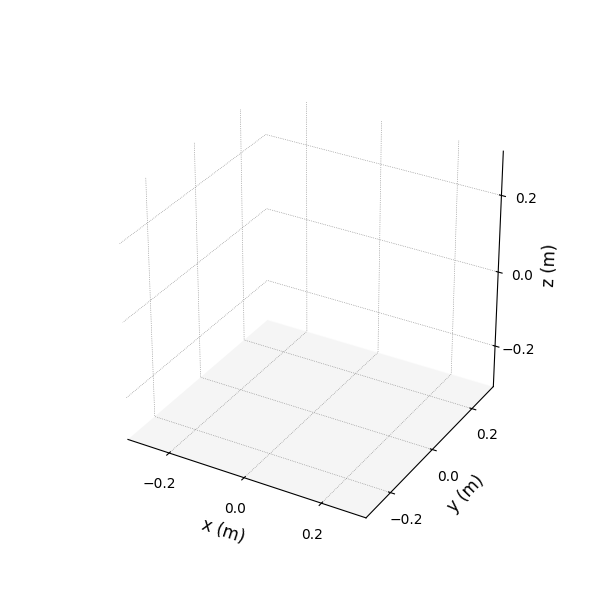

In [63]:
save_path = "../data/2024-05-15_DMD_results/02_12/"
times, markers, Lambda, Modes, bn, Psi, keypoints = load_results_npz(save_path, "02_12_334")

print(markers.shape)
print(keypoints.shape)

hawk3d = Hawk3D("../data/mean_hawk_shape.csv")
animate_compare(hawk3d, keypoints_frames_list = [keypoints, markers])


Figure and axes initialized.


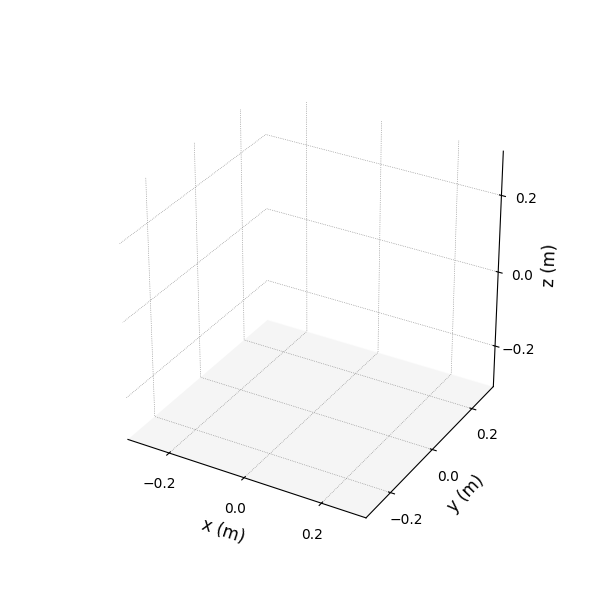

## Plan

Histogram of Lambdas
